### 서울시 행정동별 요양시설 유효공급 격차 ⑤ 검증

질문: **우리 지표가 공급이 부족하다고 한 곳의 시설이 실제로 꽉 차 있는가?**

E2SFCA 1단계의 공급비 $R_j$는 시설 j의 정원 1석당 주변 가중 수요의 역수다. 그 역수 $1/R_j$를 **시설별 수요 압력**(정원 1석당 반경 안 가중 수요)으로 보고, 압력이 높은 시설일수록 실제로 만실인지 확인한다. 만실은 E2SFCA 계산에 쓰지 않은 관측값이므로 지표의 외부 타당성 검증이 된다.

### 1. 분석 기준

- 반응변수: 만실 = 잔여정원(`정원 − 현원`) 1석 이하. 민감도: 가동률 95% 이상. 가동률은 100%에서 막히는 천장효과가 있어 이진 반응을 쓴다.
- 모형: $\text{logit}\,P(\text{만실}) = \beta \log(1/R_j) + \text{평가등급} + \log(\text{정원}) + \text{공동생활가정}$. $q$를 가동률에서 추정했으므로(03 노트북) 순환논리를 피하기 위해 평가등급을 반드시 통제한다.
- 압력 계산: 수요 버전 A, 공급 = 정원 × q(가동률 비). 반응변수가 가동률 기반이므로 **압력 계산에는 q를 넣지 않은 정원**을 쓰는 버전도 함께 본다.
- 표본: 서울 + 서울 경계 10km 안의 경기·인천 입소시설. 분석 범위가 경기·인천 전체이므로 표본 시설에서 반경 15km 안의 수요가 범위 밖(강원·충북·충남)으로 잘리지 않는지 assert로 확인한다. 모든 반경에서 같은 표본을 써야 AIC를 비교할 수 있다.
- 반경 격자: 3~15km. 반경마다 AUC와 AIC를 비교해 데이터가 지지하는 반경을 본다. 1~2km는 수요를 동 중심점 하나로 두는 해상도에 비해 너무 작아(반경 안에 동 중심점이 없는 시설이 많음) 제외한다.
- 시점 외 검증: 2024년 7월 지표·모형으로 **2025-04-01 시설별 현황**의 만실 여부를 예측한다.

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from IPython.display import display, Markdown
from sklearn.metrics import roc_auc_score

import config as C
import e2sfca as E

pd.set_option("display.max_rows", 60)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

plt.rcParams["font.family"] = ["AppleGothic", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

D0_GRID = list(range(3, 16))  # 1~2km는 동 중심점 하나로 수요를 대표하기에 너무 작아 제외
SAMPLE_KM = C.VERIFY_SAMPLE_KM
FACILITY_2025 = C.ASSET_DIR / "국민건강보험공단_장기요양기관 시설별 현황_20250401.xlsx"

### 2. 시설별 수요 압력

In [2]:
dong = gpd.read_file(C.OUTPUT_DIR / "행정동_분석범위.gpkg")
demand = pd.read_csv(C.OUTPUT_DIR / "동별_수요.csv", dtype={"행정동코드": str}).set_index("행정동코드")
dong["D"] = demand.loc[dong["행정동코드"], "D_A"].to_numpy()
fac = pd.read_csv(C.OUTPUT_DIR / "시설_공급.csv", dtype={"장기요양기관코드": str})
fac_geo = gpd.GeoSeries(gpd.points_from_xy(fac["lon"], fac["lat"]), crs="EPSG:4326").to_crs(C.CRS)

cached = np.load(C.OUTPUT_DIR / "거리행렬_동x시설.npz", allow_pickle=True)
assert list(cached["dong"]) == list(dong["행정동코드"]) and list(cached["fac"]) == list(fac["장기요양기관코드"])
dist = cached["dist"]

seoul_shape = dong.loc[dong["서울"]].union_all()
fac["서울거리_km"] = fac_geo.distance(seoul_shape).to_numpy() / 1000  # 서울 안이면 0
fac["표본"] = fac["서울거리_km"] <= SAMPLE_KM
outside = gpd.read_file(C.OUTPUT_DIR / "분석범위_밖_인접육지.gpkg").union_all()
fac["범위밖거리_km"] = fac_geo.distance(outside).to_numpy() / 1000
# assert: 검증 표본 시설의 최대 반경 안 수요가 분석 범위 밖으로 잘리지 않는다.
assert (fac.loc[fac["표본"], "범위밖거리_km"] >= max(D0_GRID)).all(), fac.loc[fac["표본"], "범위밖거리_km"].min()
print(f"검증 표본 시설에서 범위 밖 육지까지 최단거리 {fac.loc[fac['표본'], '범위밖거리_km'].min():.1f}km ≥ 최대 반경 {max(D0_GRID)}km")

supply_q = fac[f"S_{C.Q_METHOD}_{C.UNRATED_Q}"].to_numpy()
supply_raw = fac["정원"].to_numpy(dtype=float)
for d0 in D0_GRID:
    for label, S in (("q", supply_q), ("정원", supply_raw)):
        res = E.e2sfca(dong["D"].to_numpy(), S, dist, d0, C.DECAY)
        E.check_conservation(res, dong["D"].to_numpy(), S)
        # 압력 = 1 / R_j = 반경 안 가중 수요 ÷ 공급 S_j
        fac[f"압력_{label}_{d0}"] = res.weighted_demand / S

fac["만실"] = ((fac["정원"] - fac["현원"]) <= 1).astype(int)
fac["가동95"] = (fac["현원"] / fac["정원"] >= 0.95).astype(int)
fac["log정원"] = np.log(fac["정원"])
fac["등급"] = pd.Categorical(fac["등급"], categories=["A", "B", "C", "D", "E", "미평가"])

pressure_cols = [f"압력_{l}_{d0}" for l in ("q", "정원") for d0 in D0_GRID]
sample = fac.loc[fac["표본"] & (fac[pressure_cols] > 0).all(axis=1)].copy()

dropped_zero = fac["표본"].sum() - len(sample)
display(Markdown(
    f"- 표본: 서울 경계 {SAMPLE_KM}km 안 입소시설 {len(sample):,}곳 (서울 {sample['시도'].eq('서울특별시').sum()}곳, "
    f"경기·인천 {(~sample['시도'].eq('서울특별시')).sum()}곳). 반경 3km 안에 동 중심점이 없어 압력을 정의할 수 없는 시설 {dropped_zero}곳 제외\n"
    f"- 만실(잔여 1석 이하) 비율: 전체 {sample['만실'].mean():.1%}, 서울 {sample.loc[sample['시도'].eq('서울특별시'), '만실'].mean():.1%}\n"
    f"- 가동률 95% 이상 비율: {sample['가동95'].mean():.1%}"
))

검증 표본 시설에서 범위 밖 육지까지 최단거리 24.4km ≥ 최대 반경 15km


- 표본: 서울 경계 10km 안 입소시설 1,558곳 (서울 483곳, 경기·인천 1075곳). 반경 3km 안에 동 중심점이 없어 압력을 정의할 수 없는 시설 4곳 제외
- 만실(잔여 1석 이하) 비율: 전체 49.1%, 서울 67.9%
- 가동률 95% 이상 비율: 45.4%

### 3. 반경별 적합도

In [3]:
BASE_FORMULA = "등급 + log정원 + 공동생활가정"


def fit(outcome, pressure_col=None, data=sample, extra=""):
    rhs = BASE_FORMULA + extra + (f" + np.log({pressure_col})" if pressure_col else "")
    model = smf.logit(f"{outcome} ~ {rhs}", data=data).fit(disp=False)
    auc = roc_auc_score(data[outcome], model.predict(data))
    return model, auc


rows = []
for outcome in ["만실", "가동95"]:
    base_model, base_auc = fit(outcome)
    for label in ["q", "정원"]:
        for d0 in D0_GRID:
            m, auc = fit(outcome, f"압력_{label}_{d0}")
            beta = m.params[f"np.log(압력_{label}_{d0})"]
            ci = m.conf_int().loc[f"np.log(압력_{label}_{d0})"]
            rows.append({
                "반응": outcome, "공급": label, "반경(km)": d0, "AUC": auc, "ΔAUC(압력 추가)": auc - base_auc,
                "AIC": m.aic, "ΔAIC(압력 추가)": m.aic - base_model.aic,
                "β(log 압력)": beta, "OR(압력 2배)": 2 ** beta,
                "OR 95% 하한": 2 ** ci[0], "OR 95% 상한": 2 ** ci[1], "p": m.pvalues[f"np.log(압력_{label}_{d0})"],
            })
fit_table = pd.DataFrame(rows)
fit_table.to_csv(C.OUTPUT_DIR / "반경별_적합도.csv", index=False)

main = fit_table.query("반응 == '만실' and 공급 == 'q'").set_index("반경(km)")
best_d0 = int(main["AIC"].idxmin())
flat = main.index[main["AIC"] <= main["AIC"].min() + 2]
display(Markdown(
    f"압력 없는 기본 모형(등급·규모·공동생활가정)의 AUC: 만실 {fit('만실')[1]:.3f}, 가동률95 {fit('가동95')[1]:.3f}. "
    f"만실 모형에서 AIC가 가장 낮은 반경: **{best_d0}km**"
))
display(
    fit_table.query("공급 == 'q'")
    .style.format({"AUC": "{:.3f}", "ΔAUC(압력 추가)": "{:+.3f}", "AIC": "{:,.1f}", "ΔAIC(압력 추가)": "{:+.1f}",
                   "β(log 압력)": "{:.3f}", "OR(압력 2배)": "{:.2f}", "OR 95% 하한": "{:.2f}", "OR 95% 상한": "{:.2f}", "p": "{:.4f}"})
    .hide(axis="index")
)

압력 없는 기본 모형(등급·규모·공동생활가정)의 AUC: 만실 0.758, 가동률95 0.617. 만실 모형에서 AIC가 가장 낮은 반경: **15km**

반응,공급,반경(km),AUC,ΔAUC(압력 추가),AIC,ΔAIC(압력 추가),β(log 압력),OR(압력 2배),OR 95% 하한,OR 95% 상한,p
만실,q,3,0.764,+0.007,"1,820.4",-18.9,0.298,1.23,1.12,1.35,0.0000
만실,q,4,0.765,+0.007,"1,819.9",-19.4,0.344,1.27,1.15,1.41,0.0000
만실,q,5,0.766,+0.008,"1,818.3",-20.9,0.370,1.29,1.16,1.44,0.0000
만실,q,6,0.766,+0.008,"1,816.9",-22.4,0.398,1.32,1.18,1.47,0.0000
만실,q,7,0.767,+0.009,"1,813.8",-25.5,0.444,1.36,1.21,1.53,0.0000
만실,q,8,0.768,+0.011,"1,810.8",-28.5,0.487,1.40,1.24,1.58,0.0000
만실,q,9,0.769,+0.011,"1,808.2",-31.1,0.527,1.44,1.27,1.64,0.0000
만실,q,10,0.770,+0.012,"1,805.7",-33.6,0.569,1.48,1.30,1.69,0.0000
만실,q,11,0.771,+0.013,"1,802.9",-36.4,0.617,1.53,1.34,1.76,0.0000
만실,q,12,0.772,+0.014,"1,800.1",-39.2,0.668,1.59,1.38,1.84,0.0000


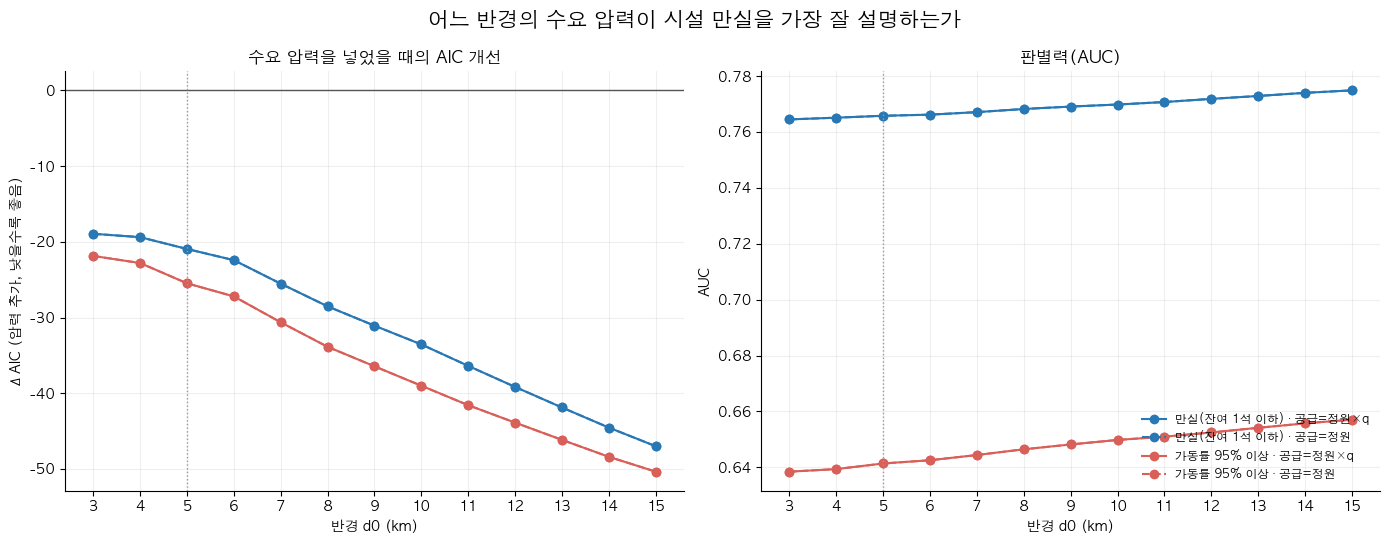

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for outcome, color in (("만실", "#2878B5"), ("가동95", "#D95F59")):
    for label, ls in (("q", "-"), ("정원", "--")):
        part = fit_table.query("반응 == @outcome and 공급 == @label")
        name = f"{'만실(잔여 1석 이하)' if outcome == '만실' else '가동률 95% 이상'} · 공급={'정원×q' if label == 'q' else '정원'}"
        axes[0].plot(part["반경(km)"], part["ΔAIC(압력 추가)"], ls, marker="o", color=color, label=name)
        axes[1].plot(part["반경(km)"], part["AUC"], ls, marker="o", color=color, label=name)
axes[0].axhline(0, color="#555555", linewidth=1)
axes[0].set_ylabel("ΔAIC (압력 추가, 낮을수록 좋음)")
axes[1].set_ylabel("AUC")
for ax, title in ((axes[0], "수요 압력을 넣었을 때의 AIC 개선"), (axes[1], "판별력(AUC)")):
    ax.axvline(C.D0_KM, color="#999999", linestyle=":", linewidth=1)
    ax.set_xlabel("반경 d0 (km)")
    ax.set_xticks(D0_GRID)
    ax.set_title(title, fontsize=12)
    ax.grid(alpha=0.2)
    ax.spines[["top", "right"]].set_visible(False)
axes[1].legend(fontsize=8.5, frameon=False, loc="lower right")
fig.suptitle("어느 반경의 수요 압력이 시설 만실을 가장 잘 설명하는가", fontsize=15)
plt.tight_layout()
fig.savefig(C.OUTPUT_DIR / "반경별_적합도.png", dpi=200, bbox_inches="tight")
plt.show()

### 4. 회귀 결과표 (기본 반경과 최적 반경)

In [5]:
def coef_table(model):
    ci = model.conf_int()
    t = pd.DataFrame({"계수": model.params, "OR": np.exp(model.params), "OR 95% 하한": np.exp(ci[0]),
                      "OR 95% 상한": np.exp(ci[1]), "p": model.pvalues})
    return t.drop(index="Intercept")


for d0 in sorted({C.D0_KM, best_d0}):
    m, auc = fit("만실", f"압력_q_{d0}")
    display(Markdown(f"**반경 {d0}km** — 만실 로지스틱 회귀 (n = {int(m.nobs):,}, AUC = {auc:.3f}, AIC = {m.aic:,.1f}, 의사 R² = {m.prsquared:.3f})"))
    display(coef_table(m).style.format({"계수": "{:.3f}", "OR": "{:.2f}", "OR 95% 하한": "{:.2f}", "OR 95% 상한": "{:.2f}", "p": "{:.4f}"}))

**반경 5km** — 만실 로지스틱 회귀 (n = 1,558, AUC = 0.766, AIC = 1,818.3, 의사 R² = 0.166)

,계수,OR,OR 95% 하한,OR 95% 상한,p
등급[T.B],-0.693,0.50,0.30,0.82,0.0065
등급[T.C],-1.244,0.29,0.17,0.48,0.0000
등급[T.D],-1.308,0.27,0.15,0.49,0.0000
등급[T.E],-1.506,0.22,0.12,0.40,0.0000
등급[T.미평가],-0.894,0.41,0.26,0.65,0.0001
log정원,-0.573,0.56,0.42,0.75,0.0001
공동생활가정,0.474,1.61,1.05,2.46,0.0289
np.log(압력_q_5),0.370,1.45,1.24,1.69,0.0000


**반경 15km** — 만실 로지스틱 회귀 (n = 1,558, AUC = 0.775, AIC = 1,792.3, 의사 R² = 0.178)

,계수,OR,OR 95% 하한,OR 95% 상한,p
등급[T.B],-0.726,0.48,0.29,0.80,0.0047
등급[T.C],-1.272,0.28,0.17,0.47,0.0000
등급[T.D],-1.358,0.26,0.14,0.46,0.0000
등급[T.E],-1.575,0.21,0.11,0.38,0.0000
등급[T.미평가],-0.889,0.41,0.26,0.65,0.0002
log정원,-0.128,0.88,0.63,1.23,0.4535
공동생활가정,0.419,1.52,0.99,2.34,0.0561
np.log(압력_q_15),0.837,2.31,1.82,2.93,0.0000


**지역 간 차이인가, 지역 안의 차이인가.** 서울 시설은 경기·인천보다 수요 압력도 높고 만실 비율도 높다. 합친 표본의 압력 효과가 이 지역 간 차이에서만 나오는지 보기 위해 ① 시도(서울·경기·인천)를 통제한 모형과 ② 서울 시설만의 모형을 반경별로 적합한다.

In [6]:
seoul_sample = sample.loc[sample["시도"].eq("서울특별시")]
within_rows = []
for d0 in D0_GRID:
    col = f"np.log(압력_q_{d0})"
    m_all, _ = fit("만실", f"압력_q_{d0}")
    m_sido, _ = fit("만실", f"압력_q_{d0}", extra=" + 시도")
    m_seoul, auc_seoul = fit("만실", f"압력_q_{d0}", data=seoul_sample)
    within_rows.append({
        "반경(km)": d0,
        "OR(전체)": 2 ** m_all.params[col], "p(전체)": m_all.pvalues[col],
        "OR(시도 통제)": 2 ** m_sido.params[col], "p(시도 통제)": m_sido.pvalues[col],
        "OR(서울만)": 2 ** m_seoul.params[col], "p(서울만)": m_seoul.pvalues[col],
    })
within = pd.DataFrame(within_rows).set_index("반경(km)")
within.to_csv(C.OUTPUT_DIR / "압력효과_지역통제.csv")
seoul_base_auc = fit("만실", data=seoul_sample)[1]
display(Markdown(
    f"서울 시설 {len(seoul_sample)}곳의 만실 비율 {seoul_sample['만실'].mean():.1%}. 오즈비는 수요 압력 2배당이다."
))
display(within.style.format({c: ("{:.2f}" if c.startswith("OR") else "{:.3f}") for c in within.columns}))

서울 시설 483곳의 만실 비율 67.9%. 오즈비는 수요 압력 2배당이다.

,OR(전체),p(전체),OR(시도 통제),p(시도 통제),OR(서울만),p(서울만)
반경(km),,,,,,
3,1.23,0.000,1.09,0.107,0.73,0.160
4,1.27,0.000,1.09,0.196,0.69,0.122
5,1.29,0.000,1.10,0.159,0.65,0.102
6,1.32,0.000,1.12,0.122,0.62,0.103
7,1.36,0.000,1.15,0.060,0.63,0.129
8,1.40,0.000,1.19,0.027,0.66,0.204
9,1.44,0.000,1.23,0.013,0.71,0.322
10,1.48,0.000,1.27,0.006,0.76,0.446
11,1.53,0.000,1.31,0.003,0.80,0.555


**서울 시설만의 모형: 위치(수요 압력)와 품질(평가등급) 중 무엇이 만실을 가르는가.** 서울 시설만으로 적합한 모형에서 평가등급의 오즈비와, 등급 묶음·압력을 각각 뺐을 때의 우도비 검정(LR)과 AUC 변화를 비교한다.

In [7]:
from scipy.stats import chi2

m_full, auc_full = fit("만실", f"압력_q_{C.D0_KM}", data=seoul_sample)
m_no_grade = smf.logit(f"만실 ~ log정원 + 공동생활가정 + np.log(압력_q_{C.D0_KM})", data=seoul_sample).fit(disp=False)
m_no_press, auc_no_press = fit("만실", data=seoul_sample)
auc_no_grade = roc_auc_score(seoul_sample["만실"], m_no_grade.predict(seoul_sample))
lr_grade = 2 * (m_full.llf - m_no_grade.llf)
lr_press = 2 * (m_full.llf - m_no_press.llf)
p_grade = chi2.sf(lr_grade, df=5)
p_press = chi2.sf(lr_press, df=1)

seoul_grade = coef_table(m_full).loc[lambda t: t.index.str.startswith("등급")]
seoul_grade.index = [i.split("T.")[-1].rstrip("]") for i in seoul_grade.index]
full_by_grade = seoul_sample.groupby("등급", observed=True)["만실"].agg(["size", "mean"]).rename(columns={"size": "시설수", "mean": "만실 비율"})
display(Markdown(
    f"서울 시설 {len(seoul_sample)}곳, 만실 비율 **{seoul_sample['만실'].mean():.1%}** (반경 {C.D0_KM}km 모형, AUC {auc_full:.3f})\n\n"
    f"- 평가등급 5개 범주를 뺄 때: LR = {lr_grade:.1f} (df 5, p = {p_grade:.4f}), AUC {auc_full:.3f} → {auc_no_grade:.3f}\n"
    f"- 수요 압력을 뺄 때: LR = {lr_press:.1f} (df 1, p = {p_press:.3f}), AUC {auc_full:.3f} → {auc_no_press:.3f}"
))
display(seoul_grade.join(full_by_grade).style.format({"계수": "{:.3f}", "OR": "{:.2f}", "OR 95% 하한": "{:.2f}", "OR 95% 상한": "{:.2f}", "p": "{:.4f}", "시설수": "{:,.0f}", "만실 비율": "{:.1%}"}))
seoul_occ = seoul_sample.groupby("등급", observed=True)[["현원", "정원"]].sum().pipe(lambda d: d["현원"] / d["정원"])
display(Markdown(
    f"참고: A등급 서울 시설 {int(full_by_grade.loc['A', '시설수'])}곳의 만실 비율 {full_by_grade.loc['A', '만실 비율']:.1%}. "
    f"통제 전 만실 비율은 등급 간 차이가 작은데, C~E등급은 대부분 9인 이하 공동생활가정이라 빈자리가 1석만 있어도 만실로 분류되기 쉽기 때문이다. "
    f"정원가중 가동률(서울): " + ", ".join(f"{g} {v:.1%}" for g, v in seoul_occ.items())
))

서울 시설 483곳, 만실 비율 **67.9%** (반경 5km 모형, AUC 0.766)

- 평가등급 5개 범주를 뺄 때: LR = 14.0 (df 5, p = 0.0158), AUC 0.766 → 0.757
- 수요 압력을 뺄 때: LR = 2.7 (df 1, p = 0.097), AUC 0.766 → 0.760

,계수,OR,OR 95% 하한,OR 95% 상한,p,시설수,만실 비율
B,-0.467,0.63,0.26,1.50,0.2955,100,71.0%
C,-1.212,0.30,0.12,0.73,0.0080,103,65.0%
D,-1.427,0.24,0.09,0.67,0.0064,48,64.6%
E,-1.465,0.23,0.08,0.66,0.0064,51,64.7%
미평가,-0.888,0.41,0.17,0.97,0.0435,136,70.6%


참고: A등급 서울 시설 45곳의 만실 비율 66.7%. 통제 전 만실 비율은 등급 간 차이가 작은데, C~E등급은 대부분 9인 이하 공동생활가정이라 빈자리가 1석만 있어도 만실로 분류되기 쉽기 때문이다. 정원가중 가동률(서울): A 97.3%, B 91.9%, C 90.8%, D 90.8%, E 84.3%, 미평가 86.1%

### 5. 시점 외 검증: 2025-04-01 만실 예측

2024년 7월 자료로 적합한 모형과 2024년 7월의 수요 압력으로, 약 8개월 뒤(2025-04-01) 같은 시설의 만실 여부를 예측한다. 2025년 파일에서 입소 정원이 없어진 시설(폐업·전환)은 제외한다.

In [8]:
cap25 = pd.read_excel(FACILITY_2025, sheet_name="입소인원", dtype={"장기요양기관코드": str})
res25 = (
    cap25.loc[cap25["기관유형코드"].isin(C.RESIDENTIAL_CODES)]
    .groupby("장기요양기관코드", as_index=False)[["정원", "현원"]].sum()
    .rename(columns={"정원": "정원_2025", "현원": "현원_2025"})
)
oot = sample.merge(res25, on="장기요양기관코드", how="inner", validate="one_to_one")
oot = oot.loc[oot["정원_2025"] > 0].copy()
oot["만실_2025"] = ((oot["정원_2025"] - oot["현원_2025"]) <= 1).astype(int)

oot_rows = []
for d0 in D0_GRID:
    m, _ = fit("만실", f"압력_q_{d0}")
    oot_rows.append({"반경(km)": d0, "AUC(2025)": roc_auc_score(oot["만실_2025"], m.predict(oot))})
base_m, _ = fit("만실")
oot_table = pd.DataFrame(oot_rows).set_index("반경(km)")
oot_base_auc = roc_auc_score(oot["만실_2025"], base_m.predict(oot))
oot_table["ΔAUC(압력 추가)"] = oot_table["AUC(2025)"] - oot_base_auc
oot_table.to_csv(C.OUTPUT_DIR / "시점외_검증.csv")

stay = pd.crosstab(oot["만실"], oot["만실_2025"], normalize="index")
display(Markdown(
    f"- 2025년에도 입소 정원이 있는 표본 시설: {len(oot):,} / {len(sample):,}곳\n"
    f"- 2025-04 만실 비율: {oot['만실_2025'].mean():.1%}. 2024-07 만실 시설 중 2025-04에도 만실: {stay.loc[1, 1]:.1%}, "
    f"2024-07 비만실 시설 중 2025-04 만실: {stay.loc[0, 1]:.1%}\n"
    f"- 압력 없는 기본 모형의 2025 AUC: {oot_base_auc:.3f}"
))
display(oot_table.style.format({"AUC(2025)": "{:.3f}", "ΔAUC(압력 추가)": "{:+.3f}"}))

- 2025년에도 입소 정원이 있는 표본 시설: 1,468 / 1,558곳
- 2025-04 만실 비율: 48.1%. 2024-07 만실 시설 중 2025-04에도 만실: 79.1%, 2024-07 비만실 시설 중 2025-04 만실: 18.7%
- 압력 없는 기본 모형의 2025 AUC: 0.763

,AUC(2025),ΔAUC(압력 추가)
반경(km),,
3,0.769,+0.006
4,0.769,+0.006
5,0.770,+0.007
6,0.770,+0.007
7,0.770,+0.008
8,0.771,+0.009
9,0.772,+0.010
10,0.773,+0.010
11,0.773,+0.011


### 6. 보고서 문장

In [9]:
# ④(04 노트북)와 ⑤를 잇는 문장: 품질 가중 민감도는 04 노트북 산출물에서 읽는다.
grid = pd.read_csv(C.OUTPUT_DIR / "민감도_격자.csv")
bin_row = grid.query("`반경(km)` == @C.D0_KM and `q 방식` == 'binary' and 수요 == 'D_A' and 미평가 == 'seoul_mean' and 감쇠 == 'gaussian'").iloc[0]
occ_by_grade = seoul_sample.groupby("등급", observed=True)[["현원", "정원"]].sum().pipe(lambda d: d["현원"] / d["정원"])
bridge_sentence = (
    f"동별 접근성 격차는 시설의 위치와 정원 규모에서 나온다. 품질 가중치를 'A·B등급 1, 나머지 0.5'로 극단적으로 바꿔도 "
    f"동 순위 상관이 {bin_row['순위 상관']:.3f}이어서 순위가 거의 그대로다. 반면 남은 빈자리가 어디에 있는지는 평가등급과 더 관련된다. "
    f"서울 입소시설의 정원가중 가동률은 A등급 {occ_by_grade['A']:.0%}, E등급 {occ_by_grade['E']:.0%}다."
)
display(Markdown(f"> {bridge_sentence}"))
print(bridge_sentence)

> 동별 접근성 격차는 시설의 위치와 정원 규모에서 나온다. 품질 가중치를 'A·B등급 1, 나머지 0.5'로 극단적으로 바꿔도 동 순위 상관이 0.993이어서 순위가 거의 그대로다. 반면 남은 빈자리가 어디에 있는지는 평가등급과 더 관련된다. 서울 입소시설의 정원가중 가동률은 A등급 97%, E등급 84%다.

동별 접근성 격차는 시설의 위치와 정원 규모에서 나온다. 품질 가중치를 'A·B등급 1, 나머지 0.5'로 극단적으로 바꿔도 동 순위 상관이 0.993이어서 순위가 거의 그대로다. 반면 남은 빈자리가 어디에 있는지는 평가등급과 더 관련된다. 서울 입소시설의 정원가중 가동률은 A등급 97%, E등급 84%다.


In [10]:
m5, auc5 = fit("만실", f"압력_q_{C.D0_KM}")
m5_base_auc = fit("만실")[1]
b5 = m5.params[f"np.log(압력_q_{C.D0_KM})"]
ci5 = m5.conf_int().loc[f"np.log(압력_q_{C.D0_KM})"]
p5 = m5.pvalues[f"np.log(압력_q_{C.D0_KM})"]
aic_rank = main["AIC"].rank().astype(int)
sentence = (
    f"지표가 실제 이용과 맞는지 확인하기 위해, 시설별 수요 압력(정원 1석당 반경 {C.D0_KM}km 안의 가중 수요)이 "
    f"높은 시설일수록 실제로 만실(잔여정원 1석 이하)인지 서울과 인근 경기·인천 입소시설 {len(sample):,}곳으로 분석했다. "
    f"평가등급·정원 규모·공동생활가정 여부를 통제해도 수요 압력이 2배 높은 시설은 만실일 오즈가 "
    f"{2 ** b5:.2f}배(95% 신뢰구간 {2 ** ci5[0]:.2f}~{2 ** ci5[1]:.2f}, p {'< 0.001' if p5 < 0.001 else f'= {p5:.3f}'})였다. "
    f"반경 {min(D0_GRID)}~{max(D0_GRID)}km 가운데 AIC는 반경이 넓을수록 낮아져 {best_d0}km에서 가장 낮았다"
    + ("(격자의 끝이라 더 넓은 반경일 가능성도 있다). " if best_d0 == max(D0_GRID) else f"(최솟값과 2 이내: {flat.min()}~{flat.max()}km). ")
    + f"그러나 이 관계는 주로 서울과 경기·인천 사이의 차이에서 나온다. 시도를 통제하면 반경 {C.D0_KM}km 압력의 오즈비는 "
    f"{within.loc[C.D0_KM, 'OR(시도 통제)']:.2f}(p = {within.loc[C.D0_KM, 'p(시도 통제)']:.2f})로 줄고, 서울 시설 {len(seoul_sample)}곳만 보면 "
    f"{within.loc[C.D0_KM, 'OR(서울만)']:.2f}(p = {within.loc[C.D0_KM, 'p(서울만)']:.2f})로 관계가 보이지 않는다. "
    f"서울 시설의 {seoul_sample['만실'].mean():.0%}가 이미 만실이어서 서울 안의 동 간 차이는 만실 여부로 검증하기 어렵다. "
    f"즉 이 검증은 '서울 전체가 인근 수도권보다 빠듯하다'는 점을 지지하지만, "
    f"서울 안에서 어느 동이 더 부족한지는 만실 자료로 확인되지 않는다."
)
display(Markdown(f"> {sentence}"))
print(sentence)

> 지표가 실제 이용과 맞는지 확인하기 위해, 시설별 수요 압력(정원 1석당 반경 5km 안의 가중 수요)이 높은 시설일수록 실제로 만실(잔여정원 1석 이하)인지 서울과 인근 경기·인천 입소시설 1,558곳으로 분석했다. 평가등급·정원 규모·공동생활가정 여부를 통제해도 수요 압력이 2배 높은 시설은 만실일 오즈가 1.29배(95% 신뢰구간 1.16~1.44, p < 0.001)였다. 반경 3~15km 가운데 AIC는 반경이 넓을수록 낮아져 15km에서 가장 낮았다(격자의 끝이라 더 넓은 반경일 가능성도 있다). 그러나 이 관계는 주로 서울과 경기·인천 사이의 차이에서 나온다. 시도를 통제하면 반경 5km 압력의 오즈비는 1.10(p = 0.16)로 줄고, 서울 시설 483곳만 보면 0.65(p = 0.10)로 관계가 보이지 않는다. 서울 시설의 68%가 이미 만실이어서 서울 안의 동 간 차이는 만실 여부로 검증하기 어렵다. 즉 이 검증은 '서울 전체가 인근 수도권보다 빠듯하다'는 점을 지지하지만, 서울 안에서 어느 동이 더 부족한지는 만실 자료로 확인되지 않는다.

지표가 실제 이용과 맞는지 확인하기 위해, 시설별 수요 압력(정원 1석당 반경 5km 안의 가중 수요)이 높은 시설일수록 실제로 만실(잔여정원 1석 이하)인지 서울과 인근 경기·인천 입소시설 1,558곳으로 분석했다. 평가등급·정원 규모·공동생활가정 여부를 통제해도 수요 압력이 2배 높은 시설은 만실일 오즈가 1.29배(95% 신뢰구간 1.16~1.44, p < 0.001)였다. 반경 3~15km 가운데 AIC는 반경이 넓을수록 낮아져 15km에서 가장 낮았다(격자의 끝이라 더 넓은 반경일 가능성도 있다). 그러나 이 관계는 주로 서울과 경기·인천 사이의 차이에서 나온다. 시도를 통제하면 반경 5km 압력의 오즈비는 1.10(p = 0.16)로 줄고, 서울 시설 483곳만 보면 0.65(p = 0.10)로 관계가 보이지 않는다. 서울 시설의 68%가 이미 만실이어서 서울 안의 동 간 차이는 만실 여부로 검증하기 어렵다. 즉 이 검증은 '서울 전체가 인근 수도권보다 빠듯하다'는 점을 지지하지만, 서울 안에서 어느 동이 더 부족한지는 만실 자료로 확인되지 않는다.


### 7. 반경 선택 근거와 서울 안의 품질 효과

In [11]:
ext = within.loc[max(D0_GRID)]
radius_sentence = (
    f"주 반경은 {C.D0_KM}km로 두고 10km를 민감도로 제시한다. 근거는 두 가지다. 첫째, 만실 모형의 AIC는 반경을 "
    f"{min(D0_GRID)}km에서 {max(D0_GRID)}km까지 넓힐수록 계속 낮아져(수요 압력을 넣었을 때의 AIC 개선: "
    f"{C.D0_KM}km {main.loc[C.D0_KM, 'ΔAIC(압력 추가)']:+.1f}, {max(D0_GRID)}km {main.loc[max(D0_GRID), 'ΔAIC(압력 추가)']:+.1f}) "
    f"데이터로 최적 반경을 정할 수 없다. 둘째, 서울 시설만 보면 어느 반경에서도 수요 압력이 만실과 유의한 관계를 보이지 않는다"
    f"(압력 2배당 오즈비 {within['OR(서울만)'].min():.2f}~{within['OR(서울만)'].max():.2f}, p ≥ {within['p(서울만)'].min():.2f}). "
    f"넓은 반경에서의 적합도 개선은 서울 도심과 수도권 외곽 사이의 광역 차이를 반영한 것으로 보이며, 동 단위 격차를 가려내는 "
    f"근거로 삼기 어렵다."
)
assert (within["p(서울만)"] > 0.05).all() and main["AIC"].idxmin() == max(D0_GRID)

b_row = seoul_grade.loc["B"]
cde = seoul_grade.loc[["C", "D", "E"]]
quality_sentence = (
    f"서울 안에서 시설의 충원 정도는 주변 수요(위치)보다 평가등급과 더 뚜렷하게 관련된다. 정원가중 가동률은 "
    f"A등급 {seoul_occ['A']:.0%}, E등급 {seoul_occ['E']:.0%}이고, 서울 시설 {len(seoul_sample)}곳만 본 모형에서 정원 규모와 "
    f"공동생활가정 여부를 통제하면 C~E등급 시설이 만실일 오즈는 A등급의 {cde['OR'].min():.2f}~{cde['OR'].max():.2f}배"
    f"(95% 신뢰구간 하한 {cde['OR 95% 하한'].min():.2f}, 상한 {cde['OR 95% 상한'].max():.2f})였다. 반면 B등급과 A등급의 차이는 "
    f"유의하지 않았다(오즈비 {b_row['OR']:.2f}, 95% 신뢰구간 {b_row['OR 95% 하한']:.2f}~{b_row['OR 95% 상한']:.2f}). "
    f"평가등급은 2021~2022년에 측정되어 가동률(2024년 7월)보다 앞선다. 평가 시점이 가동률보다 앞서 시간 순서는 "
    f"등급→충원 방향과 부합하지만, 인과를 확정하지는 않는다."
)
assert b_row["p"] > 0.05 and (cde["p"] < 0.05).all()
for t in (radius_sentence, quality_sentence):
    display(Markdown(f"> {t}"))
    print(t)

> 주 반경은 5km로 두고 10km를 민감도로 제시한다. 근거는 두 가지다. 첫째, 만실 모형의 AIC는 반경을 3km에서 15km까지 넓힐수록 계속 낮아져(수요 압력을 넣었을 때의 AIC 개선: 5km -20.9, 15km -47.0) 데이터로 최적 반경을 정할 수 없다. 둘째, 서울 시설만 보면 어느 반경에서도 수요 압력이 만실과 유의한 관계를 보이지 않는다(압력 2배당 오즈비 0.62~0.94, p ≥ 0.10). 넓은 반경에서의 적합도 개선은 서울 도심과 수도권 외곽 사이의 광역 차이를 반영한 것으로 보이며, 동 단위 격차를 가려내는 근거로 삼기 어렵다.

주 반경은 5km로 두고 10km를 민감도로 제시한다. 근거는 두 가지다. 첫째, 만실 모형의 AIC는 반경을 3km에서 15km까지 넓힐수록 계속 낮아져(수요 압력을 넣었을 때의 AIC 개선: 5km -20.9, 15km -47.0) 데이터로 최적 반경을 정할 수 없다. 둘째, 서울 시설만 보면 어느 반경에서도 수요 압력이 만실과 유의한 관계를 보이지 않는다(압력 2배당 오즈비 0.62~0.94, p ≥ 0.10). 넓은 반경에서의 적합도 개선은 서울 도심과 수도권 외곽 사이의 광역 차이를 반영한 것으로 보이며, 동 단위 격차를 가려내는 근거로 삼기 어렵다.


> 서울 안에서 시설의 충원 정도는 주변 수요(위치)보다 평가등급과 더 뚜렷하게 관련된다. 정원가중 가동률은 A등급 97%, E등급 84%이고, 서울 시설 483곳만 본 모형에서 정원 규모와 공동생활가정 여부를 통제하면 C~E등급 시설이 만실일 오즈는 A등급의 0.23~0.30배(95% 신뢰구간 하한 0.08, 상한 0.73)였다. 반면 B등급과 A등급의 차이는 유의하지 않았다(오즈비 0.63, 95% 신뢰구간 0.26~1.50). 평가등급은 2021~2022년에 측정되어 가동률(2024년 7월)보다 앞선다. 평가 시점이 가동률보다 앞서 시간 순서는 등급→충원 방향과 부합하지만, 인과를 확정하지는 않는다.

서울 안에서 시설의 충원 정도는 주변 수요(위치)보다 평가등급과 더 뚜렷하게 관련된다. 정원가중 가동률은 A등급 97%, E등급 84%이고, 서울 시설 483곳만 본 모형에서 정원 규모와 공동생활가정 여부를 통제하면 C~E등급 시설이 만실일 오즈는 A등급의 0.23~0.30배(95% 신뢰구간 하한 0.08, 상한 0.73)였다. 반면 B등급과 A등급의 차이는 유의하지 않았다(오즈비 0.63, 95% 신뢰구간 0.26~1.50). 평가등급은 2021~2022년에 측정되어 가동률(2024년 7월)보다 앞선다. 평가 시점이 가동률보다 앞서 시간 순서는 등급→충원 방향과 부합하지만, 인과를 확정하지는 않는다.


### 해석상 주의

- 만실은 수요 외에도 운영 방침(대기자 관리), 비용, 입지 선호의 영향을 받는다. 서울은 시설 대부분이 만실이라 반응변수에 천장효과가 있어, 서울 안의 동 간 차이를 검증하기에는 검정력이 낮다. 서울 안의 순위를 검증하려면 주소지별 입소자 이용 자료(수요자가 실제로 어느 시설에 입소했는지)나 시설별 대기자 수가 필요하다.
- 압력은 E2SFCA 1단계의 분모(반경 안 가중 수요)에서 나오므로, 이 검증은 1단계(시설 쪽)를 직접 검증하고 2단계(동 쪽 접근성)는 간접적으로만 검증한다.
- 2025년 표본은 2024년 표본 중 운영이 이어진 시설이며, 그 사이 새로 생긴 시설은 포함하지 않는다.

### 출처

- 국민건강보험공단_장기요양기관 시설별 현황(2024-07-16, 2025-04-01): https://www.data.go.kr/data/15124763/fileData.do
- 01~04 노트북 산출물